In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

In [2]:
load_dotenv(override=True)

True

In [3]:
if os.environ.get("GOOGLE_API_KEY") is None:
    raise ValueError("GOOGLE_API_KEY is not set in the environment variables.")
else:
    llm = ChatGoogleGenerativeAI(
        model="gemini-3.5-flash-lite",
        api_key=os.environ.get("GOOGLE_API_KEY")
    )

In [7]:
## Pydantic Schema
from pydantic import BaseModel, Field
from typing import List, TypedDict, Literal
from langchain_core.prompts import ChatPromptTemplate

class llm_schema(BaseModel):
    funny_flag: Literal["funny","not funny"] = Field(description="Whether the joke is funny or not")
    feedback: str = Field(description="Feedback on the joke")

llm_with_schema = llm.with_structured_output(llm_schema)

In [5]:
## Graph Schema

class graph_schema(TypedDict):

    topic: str
    joke: str
    funny_flag: str
    feedback: str
    max_iterations: int

In [6]:
# Generate Node
def generate_node(state: graph_schema) -> graph_schema:
    

    topic = state['topic']

    if state['feedback']: # Not first iteration, generate a joke based on feedback
        response = llm.invoke(f"Please modify the following joke {state['joke']} based on the following feedback: {state['feedback']}") 
    else: # First iteration, generate a joke
        response = llm.invoke("Create only one joke about the following topic: " + topic)

    
    state['joke'] = response.content 
    return state

In [14]:
## Evaluate Node
def evaluate_node(state: graph_schema) -> graph_schema: 

    joke = state['joke']
    iteration = state['max_iterations']

    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are a comedy critic. Your job is to evaluate the following joke and provide feedback on how to make it funnier."),
        ("user", "Evaluate the following joke: {joke}\nRespond with 'funny' or 'not_funny' and provide feedback if it's not funny.")
    ])

    chain = prompt | llm_with_schema
    response = chain.invoke({"joke": joke})

    state['funny_flag'] = response.funny_flag
    state['feedback'] = response.feedback
    state['max_iterations'] = iteration + 1

    return state

In [16]:
## Condition Edge
def check_iteration(state: graph_schema) -> str:

    iteration = state['max_iterations']

    if iteration <= 5 and state['funny_flag'] != "funny":
        return "generate_node"
    else:
        return "end"

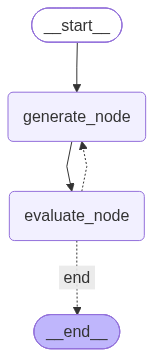

In [17]:
## Create State Graph
from langgraph.graph import StateGraph, START, END 


graph = StateGraph(graph_schema)

graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

graph.add_edge(START, "generate_node")
graph.add_edge("generate_node", "evaluate_node")
graph.add_conditional_edges("evaluate_node", check_iteration, {"generate_node": "generate_node", "end": END})

evaluator_graph = graph.compile()

from IPython.display import Image, display

# You could see the errors with the below command
Image(evaluator_graph.get_graph().draw_mermaid_png())

In [18]:
for chunk in evaluator_graph.stream(
    {
        "topic": "Cars",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "max_iterations": 0
    },
    stream_mode="updates"
):
    print(chunk)

{'generate_node': {'topic': 'Cars', 'joke': [{'type': 'text', 'text': 'Why did the car get stressed out?\n\nBecause it was under a lot of pressure!', 'extras': {'signature': 'El4KXAERTTIP7kmvTtiSHQH/LX8nq9NdDc2HpJ+z12iD0cTPILZHfaI7j+cHmzJUqXUlTV3VBfZPaM4X9bkCv67QSe++2vf3nWsUqSKYZMsBjeG9Jli20/Rb25nh/vxS'}}], 'funny_flag': '', 'feedback': '', 'max_iterations': 0}}
{'evaluate_node': {'topic': 'Cars', 'joke': [{'type': 'text', 'text': 'Why did the car get stressed out?\n\nBecause it was under a lot of pressure!', 'extras': {'signature': 'El4KXAERTTIP7kmvTtiSHQH/LX8nq9NdDc2HpJ+z12iD0cTPILZHfaI7j+cHmzJUqXUlTV3VBfZPaM4X9bkCv67QSe++2vf3nWsUqSKYZMsBjeG9Jli20/Rb25nh/vxS'}}], 'funny_flag': 'not funny', 'feedback': 'The joke relies on a predictable and overused pun. To make it funnier, try connecting the punchline to a more specific modern driving frustration, like parallel parking or dealing with navigation systems.', 'max_iterations': 1}}
{'generate_node': {'topic': 'Cars', 'joke': [{'type': 'te

## **Memory**

In [19]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages

class graph_schema(TypedDict):
    messages: Annotated[List, add_messages]

In [20]:
def welcome(schema:graph_schema) -> graph_schema:

    curr_message = schema['messages']

    response = llm.invoke(curr_message).content

    schema['messages'] = f"Your message was {curr_message}. Here's my response:  {response}"
    print("schema_messages: ",schema['messages'])

    return schema

In [21]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

# Adding Nodes
graph.add_node("welcome", welcome)

# Adding Edges
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

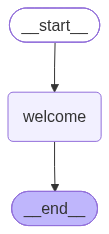

In [22]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver  

checkpoint = InMemorySaver()

memory_graph = graph.compile(checkpointer=checkpoint)

# You could see the errors with the below command
Image(memory_graph.get_graph().draw_mermaid_png())

In [27]:
response = memory_graph.invoke(
    {"messages":"what is my name?"},
    {'configurable':{'thread_id': 'srim'}}
)

for message in response['messages']:
    message.pretty_print()

schema_messages:  Your message was [HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='0203a17f-e347-4a71-87f9-cc3759dd1fd1')]. Here's my response:  [{'type': 'text', 'text': "I don't know your name! You haven't told me yet. What should I call you?", 'extras': {'signature': 'El4KXAERTTIP1Fvf71fNRCAv2b1xUeX24yfXbAVppxdaQO4Ty4h/eeQctqIIimPxu6o0anuxdnZkak1Tv1eDyT2scqo7N/SUYN3qMIvUqbBGqXaBxFEkB4FLFh+RE7aQ'}}]
================================ Human Message =================================

what is my name?
================================ Human Message =================================

Your message was [HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='0203a17f-e347-4a71-87f9-cc3759dd1fd1')]. Here's my response:  [{'type': 'text', 'text': "I don't know your name! You haven't told me yet. What should I call you?", 'extras': {'signature': 'El4KXAERTTIP1Fvf71fNRCAv2b1xUeX24yfXbAVppxdaQO4Ty4h/eeQctqIIimPxu6o0anuxdnZk

## **Human in Loop**

In [28]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import MemorySaver

In [30]:
class ExpenseState(TypedDict):
    employee: str
    amount: int
    status: str

In [31]:
def check_expense(state: ExpenseState):

    print(f"Checking expense of ₹{state['amount']}...")

    return {
        "status": "waiting_for_approval"
    }

In [32]:
def approval_node(state: ExpenseState):

    decision = interrupt(
        f"Approve ₹{state['amount']} expense for {state['employee']}? "
        "Answer True or False."
    )

    if decision:
        return Command(goto="approve")

    return Command(goto="reject")

In [33]:
def approve_node(state: ExpenseState):

    print("Expense approved!")

    return {
        "status": "approved"
    }

In [34]:
def reject_node(state: ExpenseState):

    print("Expense rejected!")

    return {
        "status": "rejected"
    }

In [35]:
builder = StateGraph(ExpenseState)

builder.add_node("check_expense", check_expense)
builder.add_node("approval", approval_node)
builder.add_node("approve", approve_node)
builder.add_node("reject", reject_node)

builder.add_edge(START, "check_expense")
builder.add_edge("check_expense", "approval")

builder.add_edge("approve", END)
builder.add_edge("reject", END)

In [36]:
checkpointer = MemorySaver()

graph = builder.compile(
    checkpointer=checkpointer
)

In [40]:
config = {
    "configurable": {
        "thread_id": "expense-001"
    }
}

result = graph.invoke(
    {
        "employee": "Srima",
        "amount": 5000,
        "status": "pending"
    },
    config=config
)

print(result)

Checking expense of ₹5000...
{'employee': 'Srima', 'amount': 5000, 'status': 'waiting_for_approval', '__interrupt__': [Interrupt(value='Approve ₹5000 expense for Srima? Answer True or False.', id='57e5fa132015db8c8d468b44a07b78ea')]}


In [41]:
resumed = graph.invoke(Command(resume=False), config=config)
print(resumed["status"])  # -> "rejected"

Expense rejected!
rejected


## *** Example*** -- so where ever in the flow we require Interrupt, we can use it there and for using the tool we can use Literal or structure_output and ask LLM to give the output in the respected format to conditionally invoke the respective path.
 

In [42]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver


class State(TypedDict):
    query: str
    result: str


def agent_node(state: State):

    print("Agent: I need database access to answer this question.")

    decision = interrupt({
        "message": "The agent wants to use the database.",
        "question": "Allow database access?"
    })

    if decision:
        return Command(goto="database")
    else:
        return Command(goto="no_database")


def database_node(state: State):

    print("Database access granted.")

    # This is NOT a real database.
    fake_result = "Database returned: 42 records"

    return {
        "result": fake_result
    }


def no_database_node(state: State):

    print("Database access denied.")

    return {
        "result": "I cannot answer this without database access."
    }


# Build graph
builder = StateGraph(State)

builder.add_node("agent", agent_node)
builder.add_node("database", database_node)
builder.add_node("no_database", no_database_node)

builder.add_edge(START, "agent")

builder.add_edge("database", END)
builder.add_edge("no_database", END)

checkpointer = MemorySaver()

graph = builder.compile(
    checkpointer=checkpointer
)